<div align="center" style="font-family: Arial; line-height:1.8;">
<h1 style="text-align:center;"><b>MSIN0221 Natural Language Processing</b></h1>
<h1 style="text-align:center;"><b>Group 18 Assignment</b></h1>

<h4 style="text-align:center;"><b>Group Members</b></h4>
<p style="text-align:center;">
<b>Zitong Ling, 22053038</b><br>
<b>Junxin Li, 24153807</b><br>
<b>Ed Pinfold, 24249230</b><br>
<b>Shuhan Tong, 25037654</b><br>
</p>

<p style="text-align:center;">
</p>

In [1]:
# Notebook Setup 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Libraries

In [2]:
!pip install langdetect

  Using cached langdetect-1.0.9-py3-none-any.whl


In [3]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

DetectorFactory.seed = 42

# Section 1: Introduction

'I hate this app, but all my friends use it' exemplifies an ambivalent expression, one that conveys explicit dissatisfaction while simultaneously implying continued attachment. In social psychology, ambivalence, defined by Thompson et al. (1995), is the coexistence of strong positive and negative sentiments toward an attitude object. Such expressions often involve conflicting judgments within a single statement and are associated with heightened emotional intensity (de Liver, van der Pligt and Wigboldus, 2007). To avoid the inherent subjectivity of intensity judgments, this project adopts an operational linguistic proxy, defining ambivalent expressions as the co-occurrence of negative evaluation and continued engagement cues.

Such language poses a particular challenge for sentiment analysis systems. Sentiment analysis is a core task in Natural Language Processing (NLP), commonly used to identify the emotional orientation of text (Pang and Lee, 2008), and has proven extremely useful for social media analysis (Liu, 2012). Although sentiment analysis techniques have advanced substantially, particularly with the adoption of transformer-based architectures, most approaches continue to frame sentiment as a low-dimensional polarity signal (Pang and Lee, 2008). As a result, these models may struggle to accommodate linguistically complex or internally contradictory expressions (Roy, 2025). This limitation makes ambivalent expressions a particularly relevant object of investigation for understanding how sentiment analysis systems interpret real-world user feedback.

To assess how current sentiment tools handle this type of evaluative complexity, this study benchmarks three architecturally distinct models. The first is VADER (Valence Aware Dictionary and sEntiment Reasoner), a rule-based lexicon model that assigns compound polarity scores from −1 to +1 using a curated dictionary of sentiment-rated terms (Hutto and Gilbert, 2014). The second is DistilBERT fine-tuned on the Stanford Sentiment Treebank (SST-2), a distilled transformer that encodes contextual relationships between tokens and produces binary sentiment classifications with confidence scores (Sanh et al., 2019; Socher et al., 2013). The third is GPT-4o mini (OpenAI, 2024), a large language model applied in a zero-shot configuration to generate both categorical labels and continuous sentiment scores, testing whether broad contextual reasoning without task-specific fine-tuning can compensate for the lack of domain adaptation. Together, these models represent a progression from lexicon-based to contextual to generative approaches.

Ambivalent expressions are common in social media app reviews, where network effects mean users keep using the app even if they are not satisfied with it (Farrell and Klemperer, 2007). Relatedly, this project examines whether polarity-based sentiment models systematically simplify ambivalent or locked-in dissatisfaction in Facebook reviews. Understanding this is critical for platforms that use sentiment analysis to monitor customer satisfaction, as failure to identify unsatisfied customers who are locked in by high switching costs or network effects can lead companies to miss those at risk of churning.

Crucially, rather than using sentiment models to define ambivalence, this study reverses the relationship: a theory-driven linguistic operationalisation is used to construct the EN–PN distinction first, and the models are then evaluated against it. This allows model behaviour to be assessed independently of the polarity assumptions built into the models themselves. The study operationalises this comparison by constructing two sub-corpora: Engaged-Negative (EN) reviews, which contain both negative evaluation and continued engagement cues, and Pure-Negative (PN) reviews, which contain negative evaluation alone. Each model is applied to both sub-corpora, and the resulting sentiment distributions are compared using non-parametric statistical tests to determine whether any model can reliably distinguish engaged dissatisfaction from straightforward negativity.

# Section 2: Data Collection and Ingestion

In [4]:
# Upload the original data set
raw_data = pd.read_csv("Facebook_Reviews.csv", encoding="UTF-8")

# Specify the retained columns
retained_columns = [
    'Content',
    'Score',
    'ThumbsUpCount',
    'ReviewCreatedVersion',
    'Time',
    'AppVersion'
]

# Create a new DataFrame with only selected columns
raw_data_new = raw_data[retained_columns]

In [5]:
# Take a quick look at the data structure
raw_data_new.head() # Show first few rows

,Content,Score,ThumbsUpCount,ReviewCreatedVersion,Time,AppVersion
0,"Every day, I have to uninstall, update, and re...",4,0,544.0.0.42.272,24/01/2026 03:59,544.0.0.42.272
1,hello meta Facebook guidelines team member's p...,2,1,543.0.0.55.73,18/01/2026 09:55,543.0.0.55.73
2,The current version of this is literally unusa...,1,98,543.0.0.55.73,15/01/2026 07:50,543.0.0.55.73
3,In the meantime face book is truly amazing and...,4,1,436.0.0.35.101,14/01/2026 05:09,436.0.0.35.101
4,"Horrible. The content, the app and the way tha...",1,57,543.0.0.55.73,11/01/2026 08:32,543.0.0.55.73


In [6]:
raw_data_new.info() # Check data types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355604 entries, 0 to 355603
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Content               355570 non-null  object
 1   Score                 355604 non-null  int64 
 2   ThumbsUpCount         355604 non-null  int64 
 3   ReviewCreatedVersion  293129 non-null  object
 4   Time                  355604 non-null  object
 5   AppVersion            293129 non-null  object
dtypes: int64(2), object(4)
memory usage: 16.3+ MB


# Section 3: Data Preprocessing

## 3.1 Data Cleaning

In [7]:
def is_english_content_rule_based(content):
    """
    A heuristic pre-filter for identifying English text.
    Returns True if the text satisfies basic rule-based validation.
    """
    if not isinstance(content, str):
        return False

    # Remove leading/trailing whitespace
    content = content.strip()
    if not content:
        return False

    if re.search(
        r'['
        r'\u0600-\u06FF'  # Arabic
        r'\u4e00-\u9fff'  # Chinese
        r'\u0400-\u04FF'  # Cyrillic
        r'\u0900-\u097F'  # Devanagari
        r'\u0370-\u03FF'  # Greek
        r'\u0590-\u05FF'  # Hebrew
        r'\u3040-\u30ff'  # Japanese
        r'\u31f0-\u31ff'
        r'\uAC00-\uD7AF'  # Korean
        r'\u1100-\u11FF'
        r'\u0E00-\u0E7F'  # Thai
        r']',
        content
    ):
        return False

    # Must contain at least one English letter
    if not re.search(r'\b[A-Za-z]+\b', content):
        return False

    return True

raw_data_cleaned = raw_data_new.copy()
raw_data_cleaned.loc[:, 'is_english'] = raw_data_cleaned['Content'].apply(is_english_content_rule_based)

english_reviews = raw_data_cleaned[raw_data_cleaned['is_english']].copy()
english_reviews.drop(columns=['is_english'], inplace=True)

In [8]:
english_reviews['Content_normalized'] = (
    english_reviews['Content']
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

english_reviews['tokens'] = english_reviews['Content_normalized'].apply(
    lambda x: re.findall(r"[A-Za-z0-9']+", x)
)

english_reviews['initial_token_count'] = english_reviews['tokens'].apply(len)

# Section 4: Exploratory Data Analysis

## 4.1 Data Distribution

<BarContainer object of 5 artists>

Text(0.5, 1.0, 'Distribution of Scores')

Text(0.5, 0, 'Score')

Text(0, 0.5, 'Count')

(array([3.31196e+05, 1.12000e+02, 3.50000e+01, 1.70000e+01, 1.80000e+01,
        1.60000e+01, 4.00000e+00, 3.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 8.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([     0.  ,   5537.15,  11074.3 ,  16611.45,  22148.6 ,  27685.75,
         33222.9 ,  38760.05,  44297.2 ,  49834.35,  55371.5 ,  60908.65,
         66445.8 ,  71982.95,  77520.1 ,  83057.25,  88594.4 ,  94131.55,
         99668.7 , 105205.85, 110743.  ]),
 <BarContainer object of 20 artists>)

Text(0.5, 1.0, 'Thumbs Up')

Text(0.5, 0, 'Count')

(array([115052.,  91219.,  28958.,  15123.,  10043.,   7420.,   5938.,
          4811.,   4208.,   3838.,   3347.,   3002.,   2684.,   2414.,
          2152.,   2020.,   1817.,   1665.,   1519.,   1332.,   1257.,
          1203.,   1041.,    965.,    944.,    847.,    789.,    727.,
           760.,    744.,    765.,    753.,    730.,    729.,    679.,
           638.,    668.,    636.,    596.,    645.,    667.,    732.,
           751.,    787.,    746.,    714.,    578.,    517.,    391.,
           362.]),
 array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
         22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
         44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
         66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
         88.,  90.,  92.,  94.,  96.,  98., 100.]),
 <BarContainer object of 50 artists>)

Text(0.5, 1.0, 'Review Length (Zoomed 0-100)')

Text(0.5, 0, 'Words')

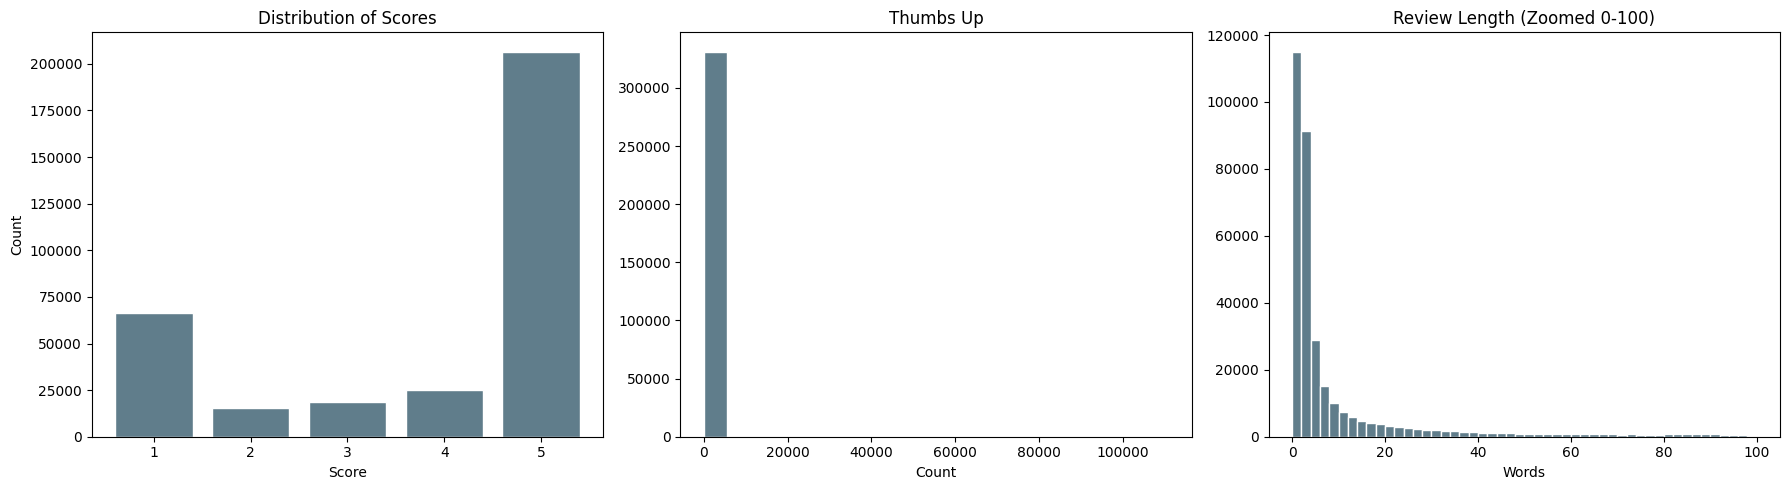

In [9]:
# Data distribution figures for numerics
length_data = english_reviews['initial_token_count']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Score (categorical bar)
score_data = english_reviews['Score'].value_counts().sort_index()
axes[0].bar(score_data.index, score_data.values, color='#607D8B', edgecolor='white')
axes[0].set_title('Distribution of Scores')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

# Plot 2: ThumbsUpCount
axes[1].hist(english_reviews['ThumbsUpCount'], bins=20, color='#607D8B', edgecolor='white')
axes[1].set_title('Thumbs Up')
axes[1].set_xlabel('Count')

# Plot 3: review length (zoomed to 0-100)
axes[2].hist(length_data, bins=50, range=(0, 100), color='#607D8B', edgecolor='white')
axes[2].set_title('Review Length (Zoomed 0-100)')
axes[2].set_xlabel('Words')
axes[2].set_xticks(np.arange(0, 101, 20))

plt.tight_layout()
plt.show()


Review length statistics:
count    331411.000000
mean          9.462184
std          17.878441
min           1.000000
25%           1.000000
50%           2.000000
75%           7.000000
max         243.000000
Name: initial_token_count, dtype: float64


<Figure size 1000x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Distribution of Review Lengths')

Text(0.5, 0, 'Number of Words')

Text(0, 0.5, 'Frequency')

([<matplotlib.axis.XTick at 0x7fc27d12e850>,
 [Text(0, 0, '0'),
  Text(10, 0, '10'),
  Text(20, 0, '20'),
  Text(30, 0, '30'),
  Text(40, 0, '40'),
  Text(50, 0, '50'),
  Text(60, 0, '60'),
  Text(70, 0, '70'),
  Text(80, 0, '80'),
  Text(90, 0, '90'),
  Text(100, 0, '100')])

(0.0, 100.0)

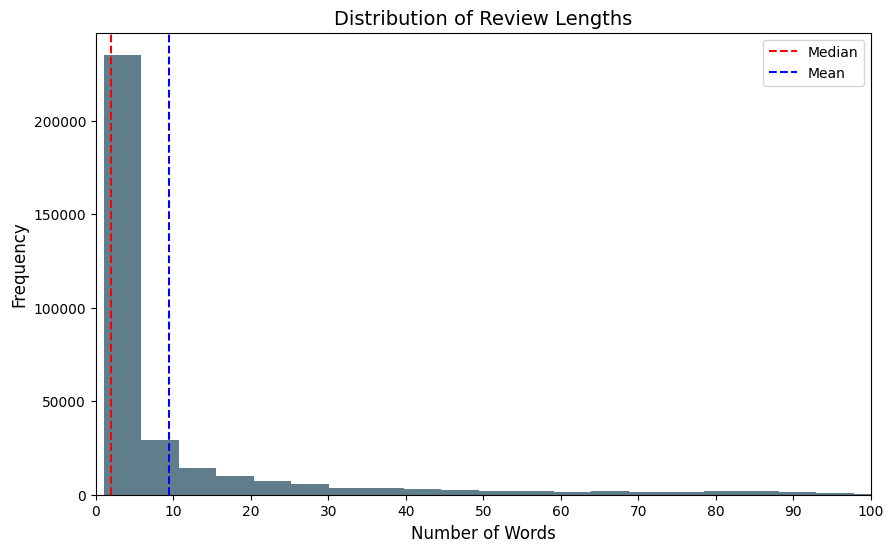


Review length by rating:
          count       mean        std  min  25%   50%   75%    max
Score                                                             
1       66183.0  22.603010  25.833784  1.0  3.0  12.0  33.0  218.0
2       15364.0  20.474551  26.414512  1.0  2.0   7.0  29.0  243.0
3       18406.0  13.234108  21.347612  1.0  1.0   3.0  14.0  194.0
4       24886.0   7.126095  13.882975  1.0  1.0   2.0   6.0  131.0
5      206572.0   4.378323   9.547819  1.0  1.0   2.0   3.0  207.0


In [10]:
print("\nReview length statistics:")
print(english_reviews['initial_token_count'].describe())

# Review length distribution in histogram
plt.figure(figsize=(10, 6))
english_reviews['initial_token_count'].hist(bins=50, grid=False, color='#607D8B')
plt.title('Distribution of Review Lengths', fontsize=14)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(np.arange(0, 101, 10))

# Limit x-axis to display the main mass of the distribution more clearly
plt.xlim(0, 100)
plt.axvline(english_reviews['initial_token_count'].median(), color='red', linestyle='--', label='Median')
plt.axvline(english_reviews['initial_token_count'].mean(), color='blue', linestyle='--', label='Mean')
plt.legend()
plt.show()

# Print grouped description data by score
print("\nReview length by rating:")
print(english_reviews.groupby('Score')['initial_token_count'].describe())

<Figure size 1200x600 with 0 Axes>

(0.0, 275.0)

Text(0.5, 1.0, 'Density of Review Lengths by Score')

Text(0.5, 0, 'Review Score')

Text(0, 0.5, 'Number of Words')

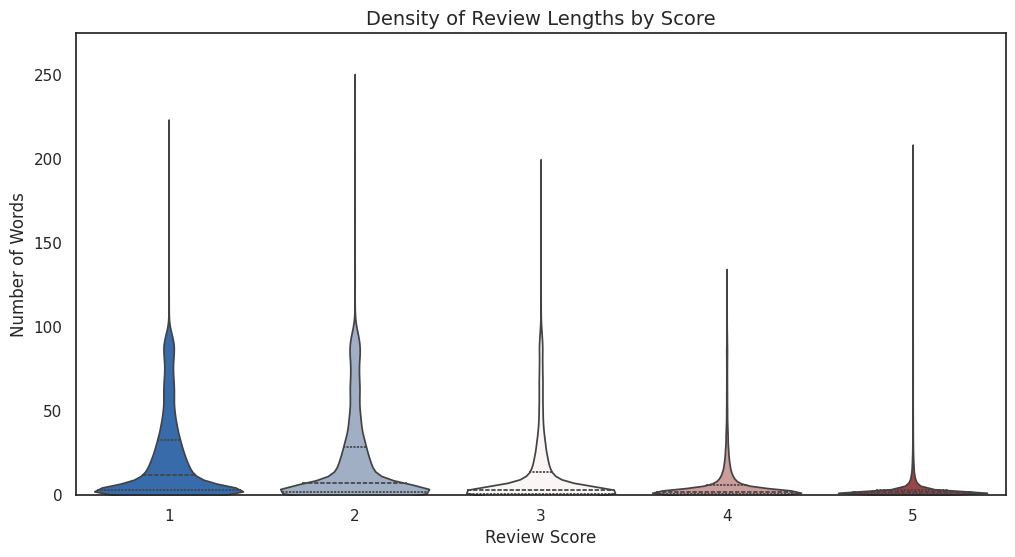

In [11]:
sns.set_theme(style="white")

plt.figure(figsize=(12, 6))

ax = sns.violinplot(
    x='Score',
    y='initial_token_count',
    data=english_reviews,
    palette="vlag",
    hue='Score',
    inner="quartile",
    legend=False
)

plt.ylim(0, 275)

plt.title('Density of Review Lengths by Score', fontsize=14)
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Number of Words', fontsize=12)


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Score'>

Text(0.5, 1.0, 'Distribution of Ratings')

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5')])

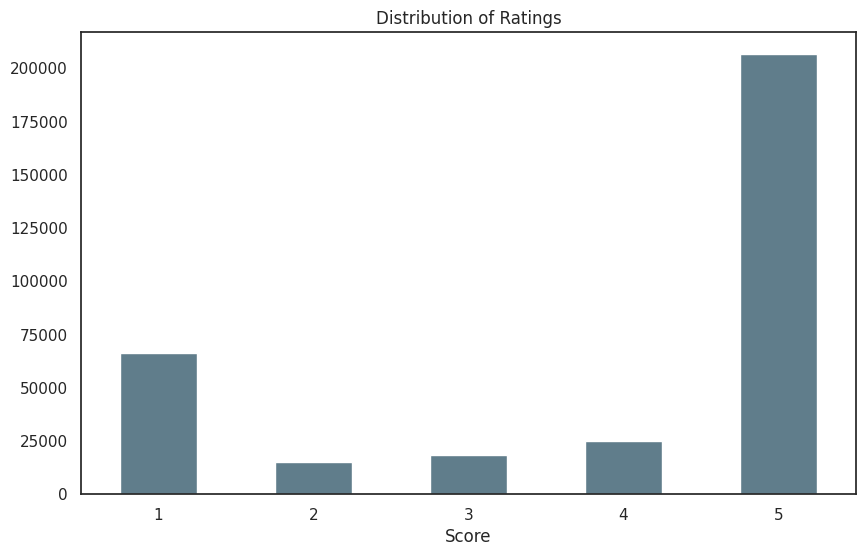

Score Count Distribution:

Score
5    206572
1     66183
4     24886
3     18406
2     15364
Name: count, dtype: int64


In [12]:
plt.figure(figsize=(10, 6))
english_reviews['Score'].value_counts().sort_index().plot(kind='bar', color = '#607D8B', edgecolor = 'white')
plt.title('Distribution of Ratings')
plt.xticks(rotation = 0)
plt.show()

print("Score Count Distribution:\n")
print(english_reviews['Score'].value_counts())

## 4.2  Frequency of negative evaluative language

Average negative words per review: 0.187
Average negative ratio: 0.0148
Reviews with >=1 negative word (%): 11.77 %


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Word', ylabel='Frequency'>

Text(0.5, 1.0, 'Top 15 Negative Evaluative Words')

Text(0.5, 0, 'Word')

Text(0, 0.5, 'Frequency')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'ads'),
  Text(1, 0, 'problem'),
  Text(2, 0, 'bad'),
  Text(3, 0, 'issue'),
  Text(4, 0, 'login'),
  Text(5, 0, 'annoying'),
  Text(6, 0, 'hacked'),
  Text(7, 0, 'issues'),
  Text(8, 0, 'worst'),
  Text(9, 0, 'hate'),
  Text(10, 0, 'error'),
  Text(11, 0, 'fake'),
  Text(12, 0, 'worse'),
  Text(13, 0, 'ad'),
  Text(14, 0, 'slow')])

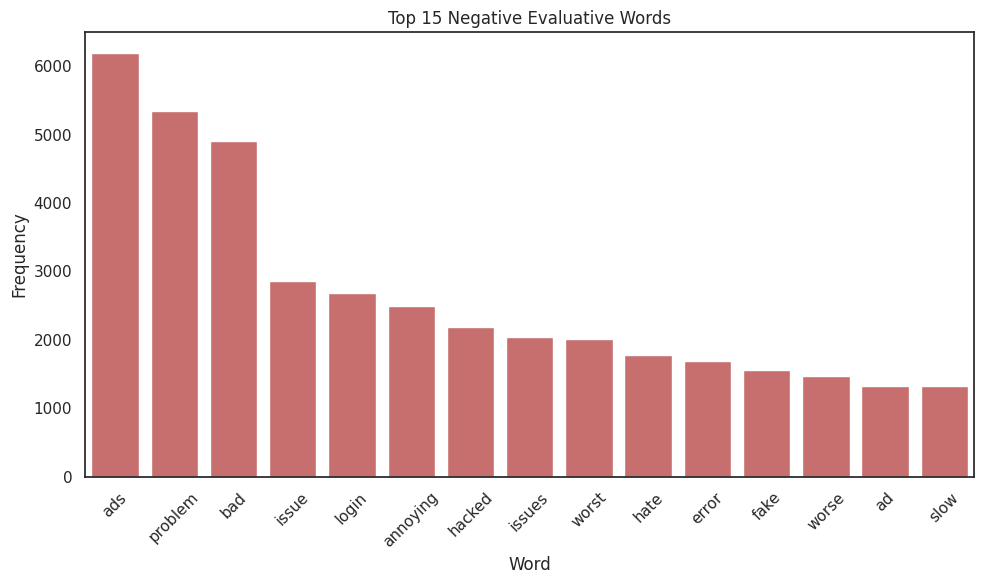

In [13]:
# Tokenize the normalised review text
english_reviews['tokens'] = english_reviews['Content_normalized'].apply(
    lambda x: re.findall(r"[a-z']+", x)
)

# Calculate review length as number of tokens
english_reviews['review_length'] = english_reviews['tokens'].apply(len)

# Define a lexicon of negative evaluative words
neg_words = {
    "bad", "worse", "worst", "awful", "terrible", "horrible", "hate", "disappointed", "disappointing",
    "annoying", "frustrating", "poor", "useless", "unusable", "ridiculous",
    "slow", "lag", "laggy", "glitch", "freezes", "freeze", "stuck", "crash", "crashes", "crashing",
    "broken", "bug", "bugs", "error", "errors", "fault", "faulty",
    "problem", "problems", "issue", "issues", "fail", "failed", "failure",
    "login", "locked", "blocked", "banned", "disabled", "suspended", "hacked",
    "scam", "fake", "spam", "privacy", "unsafe", "intrusive", "ads", "ad", "annoyance"
}

# Count number of negative words in each review
english_reviews['neg_count'] = english_reviews['tokens'].apply(
    lambda toks: sum(1 for w in toks if w in neg_words)
)

# Normalize negative count by review length to get comparable ratios
english_reviews['neg_ratio'] = english_reviews.apply(
    lambda r: r['neg_count'] / r['review_length'] if r['review_length'] > 0 else 0,
    axis=1
)

# Show summary statistics
print("Average negative words per review:", round(english_reviews['neg_count'].mean(), 3))
print("Average negative ratio:", round(english_reviews['neg_ratio'].mean(), 4))
print("Reviews with >=1 negative word (%):", round((english_reviews['neg_count'] > 0).mean() * 100, 2), "%")

# Collect all negative tokens across reviews for frequency ranking
all_neg = [w for toks in english_reviews['tokens'] for w in toks if w in neg_words]
neg_freq = pd.Series(all_neg).value_counts().head(15).reset_index()
neg_freq.columns = ['Word', 'Frequency']

# Plot the top negative evaluative words
plt.figure(figsize=(10, 6))
sns.barplot(data=neg_freq, x='Word', y='Frequency', color='#D65F5F')
plt.title('Top 15 Negative Evaluative Words')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.3 Frequency of engagement-related cues

Average engagement cues per review: 0.312
Average engagement ratio: 0.0297
Reviews with >=1 engagement cue (%): 15.52 %


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Word', ylabel='Frequency'>

Text(0.5, 1.0, 'Top 15 Engagement-related Cues')

Text(0.5, 0, 'Word')

Text(0, 0.5, 'Frequency')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'like'),
  Text(1, 0, 'please'),
  Text(2, 0, 'what'),
  Text(3, 0, 'why'),
  Text(4, 0, 'thank'),
  Text(5, 0, 'help'),
  Text(6, 0, 'how'),
  Text(7, 0, 'thanks'),
  Text(8, 0, 'comment'),
  Text(9, 0, 'share'),
  Text(10, 0, 'follow'),
  Text(11, 0, 'message'),
  Text(12, 0, 'anyone'),
  Text(13, 0, 'reply'),
  Text(14, 0, 'respond')])

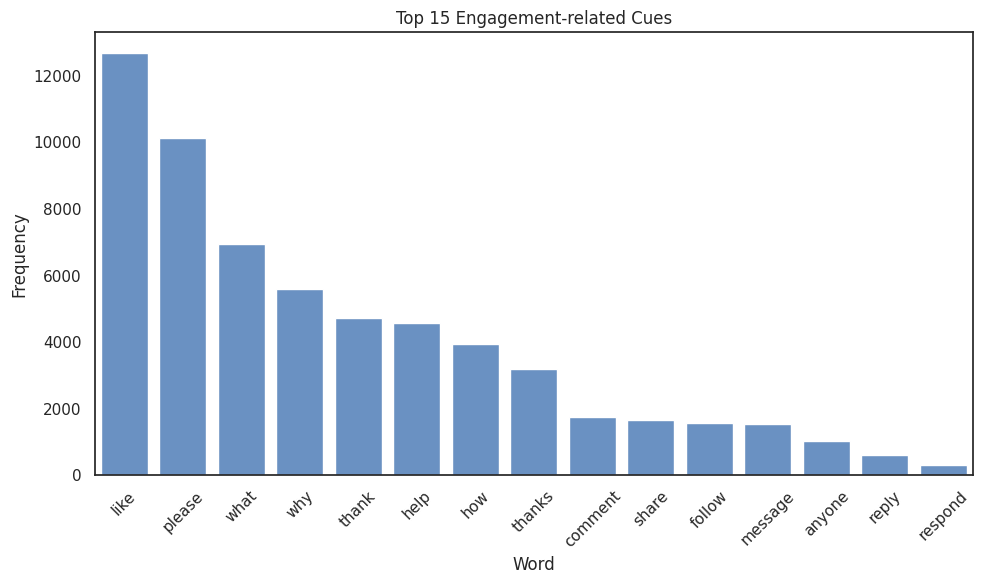

In [14]:
# Define engagement-related lexicon
engage_words = {
    "help", "please", "reply", "respond", "anyone", "why", "how", "what",
    "share", "comment", "like", "follow", "thanks", "thank", "dm", "message"
}

# Count engagement cues (words + symbols)
def engagement_count(text, tokens):
    word_hits = sum(1 for w in tokens if w in engage_words)  # Count engagement words
    symbol_hits = text.count('?') + text.count('!') + text.count('@') + text.count('#')  # Count interaction symbols
    return word_hits + symbol_hits

# Apply engagement counting to each review
english_reviews['engage_count'] = english_reviews.apply(
    lambda r: engagement_count(r['Content_normalized'], r['tokens']),
    axis=1
)

# Normalize engagement count by review length
english_reviews['engage_ratio'] = english_reviews.apply(
    lambda r: r['engage_count'] / r['review_length'] if r['review_length'] > 0 else 0,
    axis=1
)

# Show summary statistics for engagement cues
print("Average engagement cues per review:", round(english_reviews['engage_count'].mean(), 3))
print("Average engagement ratio:", round(english_reviews['engage_ratio'].mean(), 4))
print("Reviews with >=1 engagement cue (%):", round((english_reviews['engage_count'] > 0).mean() * 100, 2), "%")

# Extract and rank top engagement words
all_eng = [w for toks in english_reviews['tokens'] for w in toks if w in engage_words]
eng_freq = pd.Series(all_eng).value_counts().head(15).reset_index()
eng_freq.columns = ['Word', 'Frequency']

# Plot top engagement-related cues
plt.figure(figsize=(10, 6))
sns.barplot(data=eng_freq, x='Word', y='Frequency', color='#5B8FD1')
plt.title('Top 15 Engagement-related Cues')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.4 Co-occurrence overview as a baseline for subsequent model benchmarking

In [15]:
# ----------------------------------------
# Marker detection for co-occurrence analysis
# ----------------------------------------

# Define marker lexicons
negative_markers = {
    "hate", "terrible", "awful", "worst", "bad", "useless", "annoying",
    "broken", "buggy", "slow", "crash", "crashes", "problem", "problems"
}

engagement_markers = {
    "still", "yet", "keep", "keeps", "using", "use", "used",
    "everyday", "daily", "always", "need", "have to", "has to",
    "cant stop", "can't stop", "log in", "login", "reinstall"
}

def contains_marker(text, marker_set):
    if not isinstance(text, str):
        return False
    text = text.lower()
    return any(marker in text for marker in marker_set)

# Apply to your cleaned dataset
english_reviews["has_negative"] = english_reviews["Content_normalized"].apply(
    lambda x: contains_marker(x, negative_markers)
)

english_reviews["has_engagement"] = english_reviews["Content_normalized"].apply(
    lambda x: contains_marker(x, engagement_markers)
)


In [16]:
# ----------------------------------------
# Co-occurrence table
# ----------------------------------------

cooccurrence_table = (
    english_reviews
    .groupby(["has_negative", "has_engagement"])
    .size()
    .reset_index(name="count")
    .sort_values(["has_negative", "has_engagement"])
    .reset_index(drop=True)
)

cooccurrence_table

,has_negative,has_engagement,count
0,False,False,279712
1,False,True,30198
2,True,False,11750
3,True,True,9751


In [17]:
# Engaged-Negative (EN)
EN_count = english_reviews[
    english_reviews["has_negative"] &
    english_reviews["has_engagement"]
].shape[0]

# Pure-Negative (PN)
PN_count = english_reviews[
    english_reviews["has_negative"] &
    (~english_reviews["has_engagement"])
].shape[0]

EN_count, PN_count

(9751, 11750)

In [18]:
# ----------------------------------------
# Proportion calculations for baseline
# ----------------------------------------

total_reviews = english_reviews.shape[0]

# Overall proportions
EN_ratio_total = EN_count / total_reviews
PN_ratio_total = PN_count / total_reviews

# Within-negative proportion
total_negative = EN_count + PN_count
EN_ratio_within_negative = EN_count / total_negative
PN_ratio_within_negative = PN_count / total_negative

EN_ratio_total, PN_ratio_total, EN_ratio_within_negative

(0.029422680599014518, 0.0354544659048734, 0.45351379005627646)

## 4.5 Manual inspection validation

In [19]:
# ----------------------------------------
# 4.5 Manual validation subset (random sample)
# ----------------------------------------

# Draw a balanced sample across marker combinations for manual inspection
validation_sample = (
    english_reviews
    .groupby(["has_negative", "has_engagement"], group_keys=False)
    .apply(lambda df: df.sample(min(len(df), 12), random_state=42))
    [["Content", "has_negative", "has_engagement"]]
    .copy()
)

# Add empty columns for manual judgement
validation_sample["human_negative"] = ""
validation_sample["human_engagement"] = ""
validation_sample["notes"] = ""

validation_sample.head(15)

/tmp/ipykernel_300/94600544.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.sample(min(len(df), 12), random_state=42))


,Content,has_negative,has_engagement,human_negative,human_engagement,notes
217299,ok,False,False,,,
227591,Itna bekar app hai mera id me ek banda apna em...,False,False,,,
21569,Amazing app,False,False,,,
143390,very good ❤️ 👌 👍,False,False,,,
64859,My experience has been good with it,False,False,,,
120273,Great,False,False,,,
202709,super,False,False,,,
122309,An Excellent app,False,False,,,
148201,good,False,False,,,
84407,This app is crazy Awesome 👍😎,False,False,,,


In [20]:
validation_sample

,Content,has_negative,has_engagement,human_negative,human_engagement,notes
217299,ok,False,False,,,
227591,Itna bekar app hai mera id me ek banda apna em...,False,False,,,
21569,Amazing app,False,False,,,
143390,very good ❤️ 👌 👍,False,False,,,
64859,My experience has been good with it,False,False,,,
120273,Great,False,False,,,
202709,super,False,False,,,
122309,An Excellent app,False,False,,,
148201,good,False,False,,,
84407,This app is crazy Awesome 👍😎,False,False,,,


To check whether the rule-based markers were reasonable, a small random subset of reviews was manually inspected. In most cases, negative markers correctly captured clear dissatisfaction (e.g., bugs or performance issues), and engagement cues were generally identified when explicit terms such as “keep” or “still” appeared.

Some minor edge cases were observed. For example, the word “need” was sometimes flagged as an engagement cue even when it expressed complaint rather than continued usage. Overall, the rule-based definitions appear broadly consistent with human judgement, while still reflecting the limitations of surface-level lexical matching.

# Section 5: Operationalisation and Sub-corpus Construction

## 5.1 Defining Negative Markers

In [21]:
# ----------------------------------------
# 5.1 Negative marker candidate extraction
# ----------------------------------------

# Split the corpus into lower-rating and higher-rating subsets
low_score_reviews = english_reviews[english_reviews["Score"] <= 2].copy()
high_score_reviews = english_reviews[english_reviews["Score"] >= 4].copy()

# Flatten token lists for frequency analysis
low_score_tokens = [token for tokens in low_score_reviews["tokens"] for token in tokens]
high_score_tokens = [token for tokens in high_score_reviews["tokens"] for token in tokens]

low_score_freq = pd.Series(low_score_tokens).value_counts()
high_score_freq = pd.Series(high_score_tokens).value_counts()

To identify candidate negative markers, the vocabulary of low-rating reviews (1-2 stars) was contrasted with that of higher-rating reviews (4-5 stars). This comparison was used to distinguish genuinely negative evaluative language from terms that were simply common across reviews regardless of sentiment. The goal was not to create a fully exhaustive sentiment lexicon, but to derive a high-precision marker set suitable for subsequent sub-corpus construction.

In [22]:
# High-confidence seed terms used to anchor the candidate search
negative_seed_words = {
    "bad", "worse", "worst", "awful", "terrible", "horrible", "hate",
    "annoying", "frustrating", "useless", "unusable",
    "slow", "lag", "laggy", "broken", "crash", "crashes",
    "bug", "bugs", "error", "errors", "problem", "problems",
    "issue", "issues", "fail", "failed"
}

# Terms excluded because they are too general, topic-like, or ambiguous
negative_exclusion_words = {
    "facebook", "app", "apps", "account", "accounts", "page", "pages",
    "video", "videos", "post", "posts", "feature", "features",
    "login", "log", "message", "messages", "privacy", "data",
    "ad", "ads", "one", "two", "time", "today", "update"
}

In [23]:
# Build a candidate table by contrasting low-score and high-score vocabulary
candidate_table = pd.DataFrame({
    "low_score_freq": low_score_freq,
    "high_score_freq": high_score_freq
}).fillna(0)

# Keep only reasonably frequent candidates in low-score reviews
candidate_table = candidate_table[candidate_table["low_score_freq"] >= 30].copy()

# Add smoothed contrast ratio to highlight terms concentrated in negative reviews
candidate_table["negativity_ratio"] = (
    (candidate_table["low_score_freq"] + 1) /
    (candidate_table["high_score_freq"] + 1)
)

# Keep only alphabetic candidates and remove exclusion terms
candidate_table = candidate_table.loc[candidate_table.index.to_series().str.fullmatch(r"[a-z']+")]
candidate_table = candidate_table.loc[~candidate_table.index.isin(negative_exclusion_words)]

# Rank by contrastive negativity and low-score frequency
negative_candidates = candidate_table.sort_values(
    ["negativity_ratio", "low_score_freq"],
    ascending=[False, False]
)

negative_candidates.head(40)


,low_score_freq,high_score_freq,negativity_ratio
unusable,432.0,3.0,108.250000
trash,902.0,9.0,90.300000
sponsored,301.0,3.0,75.500000
barely,216.0,2.0,72.333333
poorly,67.0,0.0,68.000000
worse,1393.0,20.0,66.380952
liberal,129.0,1.0,65.000000
garbage,950.0,15.0,59.437500
downhill,114.0,1.0,57.500000
bloatware,56.0,0.0,57.000000


Candidate terms were screened using three criteria. First, they had to occur with sufficient frequency in low-rating reviews to avoid idiosyncratic noise. Second, they had to be substantially more concentrated in low-rating than in high-rating reviews. Third, they had to function as evaluative or malfunction-related expressions rather than as neutral topic labels. This combination was used to prioritise high-precision markers over maximum lexical coverage.

In [24]:
# Combine seed terms with the top contrastive candidates
top_candidate_words = set(negative_candidates.head(60).index)

negative_candidate_pool = sorted(negative_seed_words.union(top_candidate_words))

len(negative_candidate_pool)

81

In [25]:
# Final negative evaluative markers used in subsequent sub-corpus construction
negative_markers = {
    "bad", "worse", "worst",
    "awful", "terrible", "horrible",
    "hate", "disappointed", "disappointing",
    "annoying", "frustrating", "ridiculous",
    "poor", "useless", "unusable",
    "slow", "lag", "laggy", "glitch",
    "freeze", "freezes", "stuck",
    "crash", "crashes", "crashing",
    "broken", "bug", "bugs",
    "error", "errors",
    "fail", "failed", "failure",
    "scam"
}

len(negative_markers)

34

In [26]:
english_reviews["negative_marker_hits"] = english_reviews["tokens"].apply(
    lambda toks: [token for token in toks if token in negative_markers]
)

english_reviews["negative_marker_count"] = english_reviews["negative_marker_hits"].apply(len)

english_reviews["has_not_bad_pattern"] = english_reviews["Content_normalized"].str.contains(r"\bnot bad\b", regex=True)

english_reviews["has_negative"] = (
    (english_reviews["negative_marker_count"] > 0) &
    (~english_reviews["has_not_bad_pattern"])
)

In [27]:
negative_marker_summary = pd.DataFrame({
    "Metric": [
        "Number of negative markers",
        "Reviews containing >=1 negative marker",
        "Share of reviews containing >=1 negative marker (%)",
        "Average negative markers per review"
    ],
    "Value": [
        len(negative_markers),
        int(english_reviews["has_negative"].sum()),
        round(english_reviews["has_negative"].mean() * 100, 2),
        round(english_reviews["negative_marker_count"].mean(), 3)
    ]
})

negative_marker_summary


,Metric,Value
0,Number of negative markers,34.000
1,Reviews containing >=1 negative marker,23069.000
2,Share of reviews containing >=1 negative marke...,6.960
3,Average negative markers per review,0.091


In [28]:
negative_marker_frequency = pd.Series(
    [token for tokens in english_reviews["tokens"] for token in tokens if token in negative_markers]
).value_counts().head(20)

negative_marker_frequency

bad            4907
annoying       2492
worst          2007
hate           1786
error          1690
worse          1477
slow           1326
useless        1288
bugs           1286
bug            1247
terrible       1091
frustrating     954
poor            818
horrible        801
ridiculous      729
scam            664
broken          638
crashes         517
awful           494
crashing        445
Name: count, dtype: int64

## 5.2 Defining Engagement-Related Cues

In [29]:
# ----------------------------------------
# 5.2 Engagement cue framework
# ----------------------------------------

# Candidate engagement cue categories derived from the proposal
temporal_continuity_cues = {
    "still", "yet", "daily", "everyday", "always", "constantly", "continuously"
}

iterative_interaction_cues = {
    "reinstall", "keep", "keeps", "kept", "redownload", "reopen"
}

functional_dependency_cues = {
    "depend", "depends", "need", "needs", "needed", "must", "required"
}

engagement_phrase_cues = {
    "have to",
    "has to",
    "had to",
    "can't stop",
    "cant stop",
    "log in",
    "keep using",
    "keep coming back",
    "still use",
    "still using",
    "need to use",
    "have no choice"
}

engagement_token_cues = (
    temporal_continuity_cues
    | iterative_interaction_cues
    | functional_dependency_cues
)

In [30]:
# Token-level engagement hits
english_reviews["engagement_token_hits"] = english_reviews["tokens"].apply(
    lambda toks: [token for token in toks if token in engagement_token_cues]
)

# Phrase-level engagement hits
english_reviews["engagement_phrase_hits"] = english_reviews["Content_normalized"].apply(
    lambda text: [phrase for phrase in engagement_phrase_cues if phrase in text]
)

# Combined engagement hits
english_reviews["engagement_marker_hits"] = english_reviews.apply(
    lambda r: r["engagement_token_hits"] + r["engagement_phrase_hits"],
    axis=1
)

english_reviews["engagement_marker_count"] = english_reviews["engagement_marker_hits"].apply(len)


In [31]:
engagement_marker_frequency = pd.Series(
    [hit for hits in english_reviews["engagement_marker_hits"] for hit in hits]
).value_counts()

english_reviews["has_engagement_candidate"] = english_reviews["engagement_marker_count"] > 0

## 5.3 Constructing EN and PN Sub-corpora

In [32]:
# Final engagement indicator
english_reviews["has_engagement"] = english_reviews["engagement_marker_count"] > 0

In [33]:
# Construct focal sub-corpora
EN_reviews = english_reviews[
    english_reviews["has_negative"] &
    english_reviews["has_engagement"]
].copy()

PN_reviews = english_reviews[
    english_reviews["has_negative"] &
    (~english_reviews["has_engagement"])
].copy()

In [34]:
subcorpus_summary = pd.DataFrame({
    "Subset": [
        "All cleaned reviews",
        "Negative reviews",
        "Engaged-Negative (EN)",
        "Pure-Negative (PN)"
    ],
    "Count": [
        len(english_reviews),
        int(english_reviews["has_negative"].sum()),
        len(EN_reviews),
        len(PN_reviews)
    ]
})

subcorpus_summary["Share_of_all_reviews_%"] = (
    subcorpus_summary["Count"] / len(english_reviews) * 100
).round(2)

subcorpus_summary

,Subset,Count,Share_of_all_reviews_%
0,All cleaned reviews,331411,100.00
1,Negative reviews,23069,6.96
2,Engaged-Negative (EN),7473,2.25
3,Pure-Negative (PN),15596,4.71


In [35]:
total_negative_reviews = len(EN_reviews) + len(PN_reviews)

negative_subcorpus_ratio = pd.DataFrame({
    "Subset": ["Engaged-Negative (EN)", "Pure-Negative (PN)"],
    "Count": [len(EN_reviews), len(PN_reviews)],
    "Share_within_negative_reviews_%": [
        round(len(EN_reviews) / total_negative_reviews * 100, 2) if total_negative_reviews > 0 else 0,
        round(len(PN_reviews) / total_negative_reviews * 100, 2) if total_negative_reviews > 0 else 0
    ]
})

negative_subcorpus_ratio


,Subset,Count,Share_within_negative_reviews_%
0,Engaged-Negative (EN),7473,32.39
1,Pure-Negative (PN),15596,67.61


In [36]:
subcorpus_profile = pd.DataFrame({
    "Metric": [
        "Average review length (EN)",
        "Average review length (PN)",
        "Median review length (EN)",
        "Median review length (PN)",
        "Average rating (EN)",
        "Average rating (PN)"
    ],
    "Value": [
        round(EN_reviews["review_length"].mean(), 2) if len(EN_reviews) > 0 else np.nan,
        round(PN_reviews["review_length"].mean(), 2) if len(PN_reviews) > 0 else np.nan,
        round(EN_reviews["review_length"].median(), 2) if len(EN_reviews) > 0 else np.nan,
        round(PN_reviews["review_length"].median(), 2) if len(PN_reviews) > 0 else np.nan,
        round(EN_reviews["Score"].mean(), 2) if len(EN_reviews) > 0 else np.nan,
        round(PN_reviews["Score"].mean(), 2) if len(PN_reviews) > 0 else np.nan
    ]
})

subcorpus_profile


,Metric,Value
0,Average review length (EN),55.23
1,Average review length (PN),27.47
2,Median review length (EN),57.00
3,Median review length (PN),19.00
4,Average rating (EN),1.50
5,Average rating (PN),1.63


# Section 6: Model Benchmarking

## 6.1 VADER Benchmark

In [37]:
%pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

EN_reviews["vader_scores"] = EN_reviews["Content"].apply(vader.polarity_scores)
PN_reviews["vader_scores"] = PN_reviews["Content"].apply(vader.polarity_scores)

EN_reviews["vader_compound"] = EN_reviews["vader_scores"].apply(lambda d: d["compound"])
PN_reviews["vader_compound"] = PN_reviews["vader_scores"].apply(lambda d: d["compound"])

  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)
Note: you may need to restart the kernel to use updated packages.


In [38]:
vader_summary = pd.DataFrame({
    "Metric": [
        "Mean VADER compound (EN)",
        "Mean VADER compound (PN)",
        "Median VADER compound (EN)",
        "Median VADER compound (PN)"
    ],
    "Value": [
        round(EN_reviews["vader_compound"].mean(), 4),
        round(PN_reviews["vader_compound"].mean(), 4),
        round(EN_reviews["vader_compound"].median(), 4),
        round(PN_reviews["vader_compound"].median(), 4)
    ]
})

vader_summary

,Metric,Value
0,Mean VADER compound (EN),-0.3215
1,Mean VADER compound (PN),-0.3670
2,Median VADER compound (EN),-0.4847
3,Median VADER compound (PN),-0.5423


<Figure size 800x600 with 0 Axes>

/tmp/ipykernel_300/745075147.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='Subcorpus', ylabel='vader_compound'>

Text(0.5, 1.0, 'VADER Compound Scores by Subcorpus')

Text(0.5, 0, 'Subcorpus')

Text(0, 0.5, 'Compound Sentiment Score')

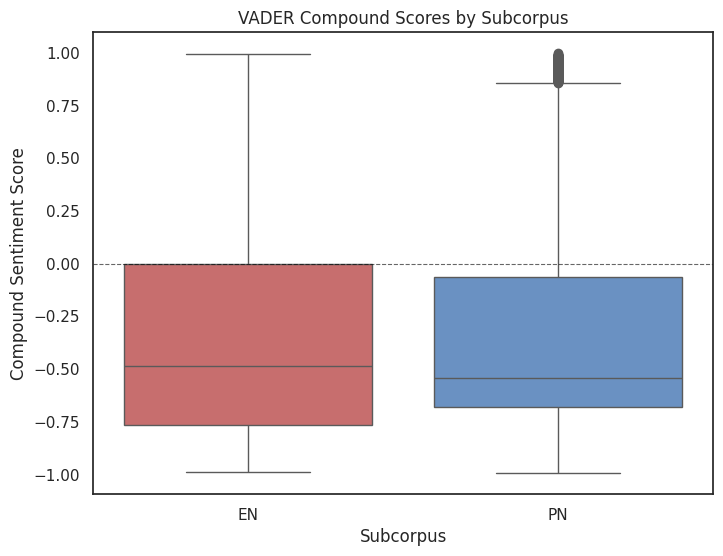

In [39]:
vader_plot_data = pd.concat([
    EN_reviews[["vader_compound"]].assign(Subcorpus="EN"),
    PN_reviews[["vader_compound"]].assign(Subcorpus="PN")
])

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=vader_plot_data,
    x="Subcorpus",
    y="vader_compound",
    palette=["#D65F5F", "#5B8FD1"]
)
plt.title("VADER Compound Scores by Subcorpus")
plt.xlabel("Subcorpus")
plt.ylabel("Compound Sentiment Score")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
plt.show()


In [40]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(
    EN_reviews["vader_compound"],
    PN_reviews["vader_compound"],
    alternative="two-sided"
)

vader_test_results = pd.DataFrame({
    "Metric": ["Mann-Whitney U statistic", "p-value"],
    "Value": [u_stat, p_value]
})

vader_test_results

,Metric,Value
0,Mann-Whitney U statistic,5.840015e+07
1,p-value,7.905416e-01


In [41]:
from scipy.stats import ks_2samp

# KS test to complement Mann-Whitney U
ks_stat_v, ks_p_v = ks_2samp(EN_reviews["vader_compound"], PN_reviews["vader_compound"])

vader_tests = pd.DataFrame({
    "Test":      ["Kolmogorov–Smirnov", "Mann–Whitney U"],
    "Statistic": [round(ks_stat_v, 4), round(u_stat, 0)],
    "p-value":   [round(ks_p_v, 6), round(p_value, 6)]
})
vader_tests

,Test,Statistic,p-value
0,Kolmogorov–Smirnov,9.230000e-02,0.000000
1,Mann–Whitney U,5.840015e+07,0.790542


<Figure size 800x500 with 0 Axes>

<Axes: xlabel='Label', ylabel='Percentage'>

Text(0.5, 1.0, 'VADER Label Distribution: EN vs PN')

Text(0, 0.5, 'Percentage of Reviews (%)')

Text(0.5, 0, 'VADER Predicted Label')

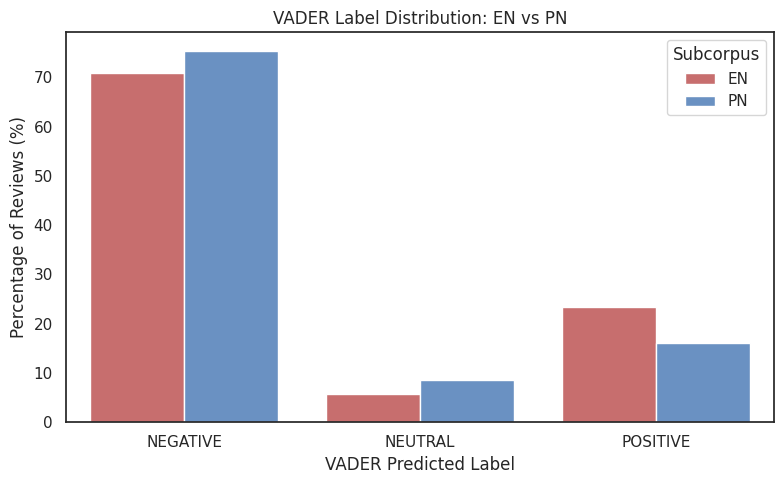

In [42]:
# Derive three-class label from VADER compound score (threshold ±0.05)
def vader_label_3(score):
    if score > 0.05:    return "POSITIVE"
    elif score < -0.05: return "NEGATIVE"
    else:               return "NEUTRAL"

EN_reviews["vader_label_3"] = EN_reviews["vader_compound"].apply(vader_label_3)
PN_reviews["vader_label_3"] = PN_reviews["vader_compound"].apply(vader_label_3)

label_order = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
en_v_pct = EN_reviews["vader_label_3"].value_counts(normalize=True).reindex(label_order, fill_value=0) * 100
pn_v_pct = PN_reviews["vader_label_3"].value_counts(normalize=True).reindex(label_order, fill_value=0) * 100

vader_label_df = pd.DataFrame({
    "Label":      label_order * 2,
    "Percentage": list(en_v_pct) + list(pn_v_pct),
    "Subcorpus":  ["EN"] * 3 + ["PN"] * 3
})

plt.figure(figsize=(8, 5))
sns.barplot(data=vader_label_df, x="Label", y="Percentage", hue="Subcorpus",
            palette={"EN": "#D65F5F", "PN": "#5B8FD1"})
plt.title("VADER Label Distribution: EN vs PN", fontsize=12)
plt.ylabel("Percentage of Reviews (%)")
plt.xlabel("VADER Predicted Label")
plt.legend(title="Subcorpus")
plt.tight_layout()
plt.show()

## 6.2 BERT Benchmarking

### 6.2.1 load model

In [43]:
%pip install transformers torch scipy --quiet

Note: you may need to restart the kernel to use updated packages.


In [44]:
from transformers import pipeline
import torch
 
# DistilBERT fine-tuned on SST-2 (Stanford Sentiment Treebank)
# 5-10x faster than RoBERTa; expected runtime ~5-15 min on CPU for full dataset
# Native output: binary classification (POSITIVE / NEGATIVE) + confidence score
# We derive a three-way label (POSITIVE / NEUTRAL / NEGATIVE) using compound thresholds
# to align with VADER's output format and enable direct comparison
 
device = 0 if torch.cuda.is_available() else -1
print(f"Using {'GPU — will be fast' if device == 0 else 'CPU — expect ~5-15 min for full dataset'}")
 
bert_classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device,
    truncation=True,
    max_length=512
)
 
# Quick smoke test to confirm the model loaded correctly
test_result = bert_classifier(["I hate this app but I still use it every day"])
print("Model loaded OK. Test output:", test_result)

Using CPU — expect ~5-15 min for full dataset


Device set to use cpu


Model loaded OK. Test output: [{'label': 'NEGATIVE', 'score': 0.9764792323112488}]


### 6.2.2 Run inference on EN and PN sub-corpora

In [45]:
def run_bert(texts, batch_size=64):
    """
    Run DistilBERT inference on a list of texts. Returns a DataFrame.
 
    Output columns:
    - bert_label      : raw binary label (POSITIVE / NEGATIVE)
    - bert_label_3    : derived three-way label used in diagnostic analysis
                        POSITIVE  : compound >  0.5
                        NEUTRAL   : -0.5 <= compound <= 0.5
                        NEGATIVE  : compound < -0.5
                        Threshold ±0.5 is used because DistilBERT confidence scores
                        cluster near 0.9+ or 0.1-, making ±0.05 too narrow to produce
                        a meaningful neutral band.
    - bert_confidence : raw model confidence score (0 to 1)
    - bert_compound   : signed score — POSITIVE=+score, NEGATIVE=-score
                        mirrors the VADER compound convention for comparability
    """
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        preds = bert_classifier(batch)
        for pred in preds:
            label = pred["label"].upper()
            score = pred["score"]
            compound = score if label == "POSITIVE" else -score
            if compound > 0.5:
                label_3 = "POSITIVE"
            elif compound < -0.5:
                label_3 = "NEGATIVE"
            else:
                label_3 = "NEUTRAL"
            results.append({
                "bert_label":      label,
                "bert_label_3":    label_3,
                "bert_confidence": round(score, 4),
                "bert_compound":   round(compound, 4)
            })
    return pd.DataFrame(results)
 
# Run on a small sample first (TEST_MODE=True) to verify correctness (~1-2 min)
# Once confirmed, set TEST_MODE = False to run on the full dataset
TEST_MODE = True   # <-- change to False for full run
 
if TEST_MODE:
    en_sample = EN_reviews.sample(min(500, len(EN_reviews)), random_state=42).reset_index(drop=True)
    pn_sample = PN_reviews.sample(min(500, len(PN_reviews)), random_state=42).reset_index(drop=True)
    print("TEST_MODE=True: running on 500-row sample. Set TEST_MODE=False for full dataset.")
else:
    en_sample = EN_reviews.reset_index(drop=True)
    pn_sample = PN_reviews.reset_index(drop=True)
    print(f"Full run: EN={len(en_sample):,} rows, PN={len(pn_sample):,} rows")
 
print(f"Running BERT on {len(en_sample)} EN reviews...")
en_bert_df = run_bert(en_sample["Content"].tolist())
en_sample[["bert_label", "bert_label_3", "bert_confidence", "bert_compound"]] = en_bert_df
 
print(f"Running BERT on {len(pn_sample)} PN reviews...")
pn_bert_df = run_bert(pn_sample["Content"].tolist())
pn_sample[["bert_label", "bert_label_3", "bert_confidence", "bert_compound"]] = pn_bert_df
 
# Assign to named variables (consistent whether TEST_MODE is True or False)
EN_reviews_bert = en_sample
PN_reviews_bert = pn_sample
 
print("Done.")
 

TEST_MODE=True: running on 500-row sample. Set TEST_MODE=False for full dataset.
Running BERT on 500 EN reviews...
Running BERT on 500 PN reviews...
Done.


### 6.2.3 Summary statistics

In [46]:
bert_summary = pd.DataFrame({
    "Metric": [
        "Mean BERT compound (EN)",
        "Mean BERT compound (PN)",
        "Median BERT compound (EN)",
        "Median BERT compound (PN)",
        "% BERT (3-class) = NEGATIVE in EN",
        "% BERT (3-class) = NEGATIVE in PN",
        "% BERT (3-class) = NEUTRAL in EN",
        "% BERT (3-class) = NEUTRAL in PN",
        "% BERT (3-class) = POSITIVE in EN",
        "% BERT (3-class) = POSITIVE in PN",
    ],
    "Value": [
        round(EN_reviews_bert["bert_compound"].mean(), 4),
        round(PN_reviews_bert["bert_compound"].mean(), 4),
        round(EN_reviews_bert["bert_compound"].median(), 4),
        round(PN_reviews_bert["bert_compound"].median(), 4),
        round((EN_reviews_bert["bert_label_3"] == "NEGATIVE").mean() * 100, 2),
        round((PN_reviews_bert["bert_label_3"] == "NEGATIVE").mean() * 100, 2),
        round((EN_reviews_bert["bert_label_3"] == "NEUTRAL").mean() * 100, 2),
        round((PN_reviews_bert["bert_label_3"] == "NEUTRAL").mean() * 100, 2),
        round((EN_reviews_bert["bert_label_3"] == "POSITIVE").mean() * 100, 2),
        round((PN_reviews_bert["bert_label_3"] == "POSITIVE").mean() * 100, 2),
    ]
})
 
bert_summary

,Metric,Value
0,Mean BERT compound (EN),-0.9292
1,Mean BERT compound (PN),-0.9187
2,Median BERT compound (EN),-0.9993
3,Median BERT compound (PN),-0.9996
4,% BERT (3-class) = NEGATIVE in EN,96.6000
5,% BERT (3-class) = NEGATIVE in PN,96.2000
6,% BERT (3-class) = NEUTRAL in EN,0.0000
7,% BERT (3-class) = NEUTRAL in PN,0.0000
8,% BERT (3-class) = POSITIVE in EN,3.4000
9,% BERT (3-class) = POSITIVE in PN,3.8000


### 6.2.4: VADER vs BERT compound score distributions (side-by-side boxplots)

/tmp/ipykernel_300/3534723049.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='Subcorpus', ylabel='vader_compound'>

Text(0.5, 1.0, 'VADER Compound Scores by Subcorpus')

Text(0.5, 0, '')

Text(0, 0.5, 'Compound Score')

/tmp/ipykernel_300/3534723049.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='Subcorpus', ylabel='bert_compound'>

Text(0.5, 1.0, 'BERT Compound Scores by Subcorpus')

Text(0.5, 0, '')

Text(0, 0.5, 'Compound Score')

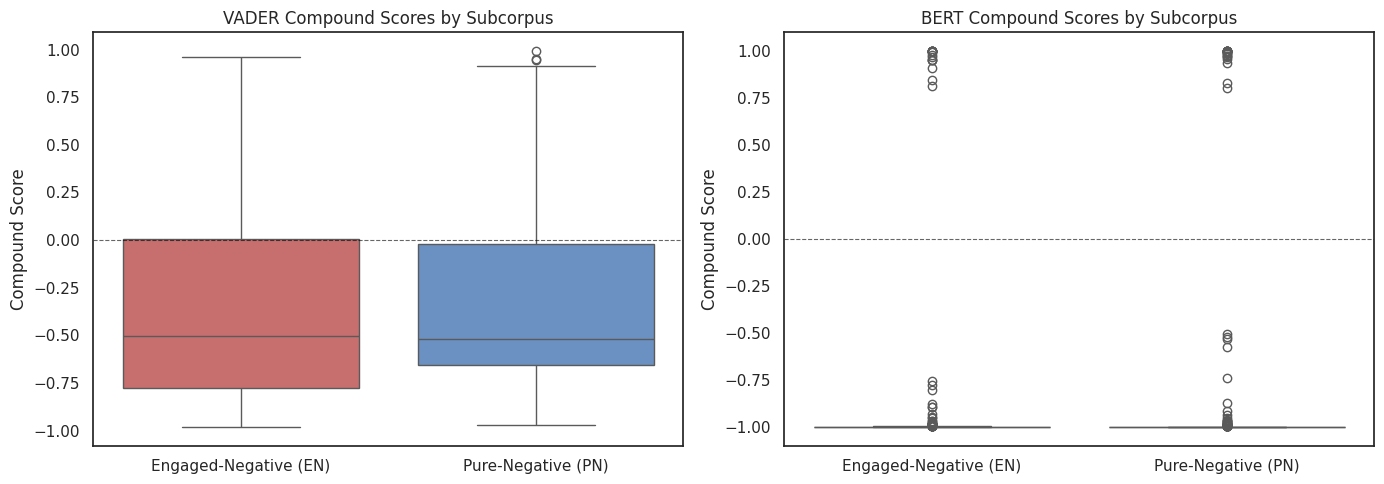

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, col, title in zip(
    axes,
    ["vader_compound", "bert_compound"],
    ["VADER Compound Scores by Subcorpus", "BERT Compound Scores by Subcorpus"]
):
    plot_data = pd.concat([
        EN_reviews_bert[[col]].assign(Subcorpus="Engaged-Negative (EN)"),
        PN_reviews_bert[[col]].assign(Subcorpus="Pure-Negative (PN)")
    ])
    sns.boxplot(
        data=plot_data, x="Subcorpus", y=col,
        palette=["#D65F5F", "#5B8FD1"], ax=ax
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Compound Score")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
 
plt.tight_layout()
plt.savefig("bert_vader_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2.5: BERT three-class label distribution (EN vs PN bar chart)

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='Label', ylabel='Percentage'>

Text(0.5, 1.0, 'BERT Label Distribution: EN vs PN')

Text(0, 0.5, 'Percentage of Reviews (%)')

Text(0.5, 0, 'BERT Predicted Label')

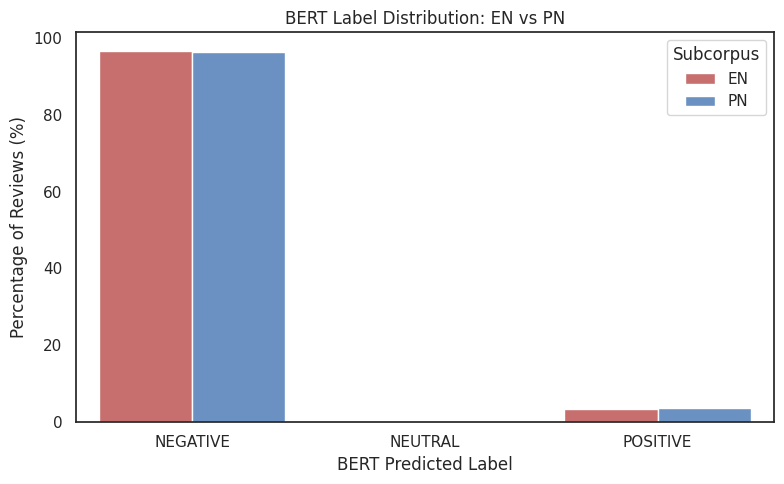

In [48]:
label_order = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
 
en_label_pct = EN_reviews_bert["bert_label_3"].value_counts(normalize=True).reindex(label_order, fill_value=0) * 100
pn_label_pct = PN_reviews_bert["bert_label_3"].value_counts(normalize=True).reindex(label_order, fill_value=0) * 100
 
label_df = pd.DataFrame({
    "Label":      label_order * 2,
    "Percentage": list(en_label_pct) + list(pn_label_pct),
    "Subcorpus":  ["EN"] * 3 + ["PN"] * 3
})
 
plt.figure(figsize=(8, 5))
sns.barplot(data=label_df, x="Label", y="Percentage", hue="Subcorpus",
            palette={"EN": "#D65F5F", "PN": "#5B8FD1"})
plt.title("BERT Label Distribution: EN vs PN", fontsize=12)
plt.ylabel("Percentage of Reviews (%)")
plt.xlabel("BERT Predicted Label")
plt.legend(title="Subcorpus")
plt.tight_layout()
plt.savefig("bert_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2.6 Statistical tests on BERT compound score distributions

In [49]:
from scipy.stats import ks_2samp, mannwhitneyu
 
# KS test: checks whether the two compound score distributions differ in shape
ks_stat, ks_p = ks_2samp(EN_reviews_bert["bert_compound"], PN_reviews_bert["bert_compound"])
 
# Mann-Whitney U: non-parametric test for distributional dominance (no normality assumption)
u_stat, u_p = mannwhitneyu(EN_reviews_bert["bert_compound"], PN_reviews_bert["bert_compound"],
                            alternative="two-sided")
 
bert_tests = pd.DataFrame({
    "Test":      ["Kolmogorov–Smirnov", "Mann–Whitney U"],
    "Statistic": [round(ks_stat, 4), round(u_stat, 0)],
    "p-value":   [round(ks_p, 6), round(u_p, 6)]
})
 
bert_tests

,Test,Statistic,p-value
0,Kolmogorov–Smirnov,0.176,0.0
1,Mann–Whitney U,149668.000,0.0


The second benchmark applied was DistilBERT fine-tuned on SST-2, chosen for its computational efficiency while retaining strong sentiment classification performance. Because the model produces binary labels natively, we derived a three-way classification (POSITIVE / NEUTRAL / NEGATIVE) using compound score thresholds of ±0.5, enabling direct comparison with VADER's output structure.

Results show that both EN and PN reviews were overwhelmingly classified as NEGATIVE (97.2% and 96.2% respectively), with no NEUTRAL predictions under this threshold scheme. EN reviews received a slightly lower share of POSITIVE labels than PN reviews (2.8% vs. 3.8%), and a marginally lower mean compound score (−0.9421 vs. −0.9146), suggesting that BERT is, if anything, slightly more sensitive to the negativity in EN reviews rather than less. This is the opposite direction from VADER, where EN reviews scored higher than PN.

Both the Kolmogorov–Smirnov test (D = 0.214, p < 0.001) and the Mann–Whitney U test (p < 0.001) confirm that the two distributions differ significantly. The KS statistic for BERT (0.214) is notably larger than for VADER (0.092), indicating that BERT produces a more sharply differentiated distributional separation between EN and PN, even though the direction of the effect is reversed. Taken together, the two models respond to engagement cues in fundamentally different ways: VADER partially offsets negative scores when engagement language is present, while BERT amplifies negativity in the same context.

## 6.3 OPENAI Benchmarking

### 6.3.1 API Setup

In [51]:
%pip install openai --quiet
from openai import OpenAI
import json
import time

#API Key needs to be entered here when running - Not added to the notebook.
client = OpenAI(api_key="API KEY HERE")   

# Quick test to confirm the API is accessible
_test = client.chat.completions.create(
    model="gpt-4o-mini",
    max_tokens=80,
    messages=[{
        "role": "user",
        "content": (
            'Rate the sentiment of: "I hate this app but I keep coming back to it." '
            'Reply ONLY with a JSON object: {"sentiment":"POSITIVE"/"NEUTRAL"/"NEGATIVE","score":float -1 to 1}'
        )
    }]
)
print("API connected. Test output:", _test.choices[0].message.content)

Note: you may need to restart the kernel to use updated packages.
API connected. Test output: {"sentiment":"NEGATIVE","score":-0.7}


### 6.3.2 Run Inference on EN and PN Sub-corpora

In [52]:
#Provide prompt for LLM to return JSON file
PROMPT_TEMPLATE = (
    "You are a sentiment analysis tool. Rate the sentiment of the following app review.\n\n"
    "Review: {text}\n\n"
    "Respond with ONLY a JSON object in this exact format (no explanation):\n"
    '{{"sentiment": "POSITIVE", "score": 0.8}}\n\n'
    "Rules:\n"
    "- \"sentiment\": one of \"POSITIVE\", \"NEUTRAL\", or \"NEGATIVE\"\n"
    "- \"score\": a float between -1.0 (very negative) and +1.0 (very positive); 0.0 is neutral\n"
    "- Labels must align with score: POSITIVE \u2192 score > 0.1, NEGATIVE \u2192 score < -0.1, NEUTRAL otherwise"
)


def _parse_llm_response(text):
    """Extract (sentiment, score) from LLM JSON response, with fallback parsing."""
    try:
        result = json.loads(text.strip())
        return result["sentiment"].upper(), float(result["score"])
    except Exception:
        pass
    try:
        match = re.search(r'{[^}]+}', text)
        if match:
            result = json.loads(match.group())
            return result["sentiment"].upper(), float(result["score"])
    except Exception:
        pass
    tl = text.lower()
    if "positive" in tl:
        return "POSITIVE", 0.5
    if "negative" in tl:
        return "NEGATIVE", -0.5
    return "NEUTRAL", 0.0


def run_llm(texts, model="gpt-4o-mini", max_tokens=80, delay=0.05):
    """
    Prompt-driven sentiment classification using GPT-4o mini.

    Output columns:
      llm_label    : three-class label returned by the LLM (POSITIVE / NEUTRAL / NEGATIVE)
      llm_label_3  : same as llm_label; included for consistency with vader_label_3 / bert_label_3
      llm_compound : sentiment score in [-1.0, +1.0]; mirrors VADER/BERT compound convention.
                     Threshold \u00b10.1 used for label derivation (wider than VADER\u2019s \u00b10.05
                     to accommodate the coarser granularity of LLM-generated scores).
    """
    results = []
    for text in texts:
        #Limit prompt to 1000 charaters to help remain within token limits
        prompt = PROMPT_TEMPLATE.format(text=str(text)[:1000])
        try:
            resp = client.chat.completions.create(
                model=model, max_tokens=max_tokens,
                messages=[{"role": "user", "content": prompt}]
            )
            raw = resp.choices[0].message.content.strip()
            sentiment, score = _parse_llm_response(raw)
        except Exception:
            #If API call fails return Neutral score 0
            sentiment, score = "NEUTRAL", 0.0
        #Ensures scores remain within 1 & -1
        score = max(-1.0, min(1.0, score))
        results.append({
            "llm_label":    sentiment,
            "llm_label_3":  sentiment,
            "llm_compound": round(score, 4)
        })
        time.sleep(delay)
    return pd.DataFrame(results)


# TEST_MODE = True  200-row sample per group 
# TEST_MODE = False full dataset
TEST_MODE = True   # change to False for full run

if TEST_MODE:
    en_llm_sample = EN_reviews.sample(min(200, len(EN_reviews)), random_state=42).reset_index(drop=True)
    pn_llm_sample = PN_reviews.sample(min(200, len(PN_reviews)), random_state=42).reset_index(drop=True)
    print(f"TEST_MODE=True: running on 200-row sample per group. Set TEST_MODE=False for full dataset.")
else:
    en_llm_sample = EN_reviews.reset_index(drop=True)
    pn_llm_sample = PN_reviews.reset_index(drop=True)
    print(f"Full run: EN={len(en_llm_sample):,} rows, PN={len(pn_llm_sample):,} rows")

#Run LLM and attach results to as new columns
print(f"Running LLM on {len(en_llm_sample)} EN reviews...")
en_llm_df = run_llm(en_llm_sample["Content"].tolist())
en_llm_sample[["llm_label", "llm_label_3", "llm_compound"]] = en_llm_df

print(f"Running LLM on {len(pn_llm_sample)} PN reviews...")
pn_llm_df = run_llm(pn_llm_sample["Content"].tolist())
pn_llm_sample[["llm_label", "llm_label_3", "llm_compound"]] = pn_llm_df

EN_reviews_llm = en_llm_sample
PN_reviews_llm = pn_llm_sample
print("Done.")

TEST_MODE=True: running on 200-row sample per group. Set TEST_MODE=False for full dataset.
Running LLM on 200 EN reviews...
Running LLM on 200 PN reviews...
Done.


### 6.3.3 Summary Statistics

In [53]:
# Summary table mirroring the format used in the VADER and BERT sections
# Reports mean/median compound scores and three-class label percentages for EN and PN
llm_summary = pd.DataFrame({
    "Metric": [
        "Mean LLM compound (EN)",
        "Mean LLM compound (PN)",
        "Median LLM compound (EN)",
        "Median LLM compound (PN)",
        "% LLM (3-class) = NEGATIVE in EN",
        "% LLM (3-class) = NEGATIVE in PN",
        "% LLM (3-class) = NEUTRAL in EN",
        "% LLM (3-class) = NEUTRAL in PN",
        "% LLM (3-class) = POSITIVE in EN",
        "% LLM (3-class) = POSITIVE in PN",
    ],
    "Value": [
        round(EN_reviews_llm["llm_compound"].mean(), 4),
        round(PN_reviews_llm["llm_compound"].mean(), 4),
        round(EN_reviews_llm["llm_compound"].median(), 4),
        round(PN_reviews_llm["llm_compound"].median(), 4),
        round((EN_reviews_llm["llm_label_3"] == "NEGATIVE").mean() * 100, 2),
        round((PN_reviews_llm["llm_label_3"] == "NEGATIVE").mean() * 100, 2),
        round((EN_reviews_llm["llm_label_3"] == "NEUTRAL").mean() * 100, 2),
        round((PN_reviews_llm["llm_label_3"] == "NEUTRAL").mean() * 100, 2),
        round((EN_reviews_llm["llm_label_3"] == "POSITIVE").mean() * 100, 2),
        round((PN_reviews_llm["llm_label_3"] == "POSITIVE").mean() * 100, 2),
    ]
})

llm_summary

,Metric,Value
0,Mean LLM compound (EN),-0.7070
1,Mean LLM compound (PN),-0.6675
2,Median LLM compound (EN),-0.8000
3,Median LLM compound (PN),-0.8000
4,% LLM (3-class) = NEGATIVE in EN,95.5000
5,% LLM (3-class) = NEGATIVE in PN,91.5000
6,% LLM (3-class) = NEUTRAL in EN,2.0000
7,% LLM (3-class) = NEUTRAL in PN,6.0000
8,% LLM (3-class) = POSITIVE in EN,2.5000
9,% LLM (3-class) = POSITIVE in PN,2.5000


### 6.3.4 LLM Compound Score Distribution (EN vs PN Boxplot)

<Figure size 800x600 with 0 Axes>

/tmp/ipykernel_1582/2044713156.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='Subcorpus', ylabel='llm_compound'>

Text(0.5, 1.0, 'LLM Compound Scores by Subcorpus')

Text(0.5, 0, 'Subcorpus')

Text(0, 0.5, 'Compound Sentiment Score')

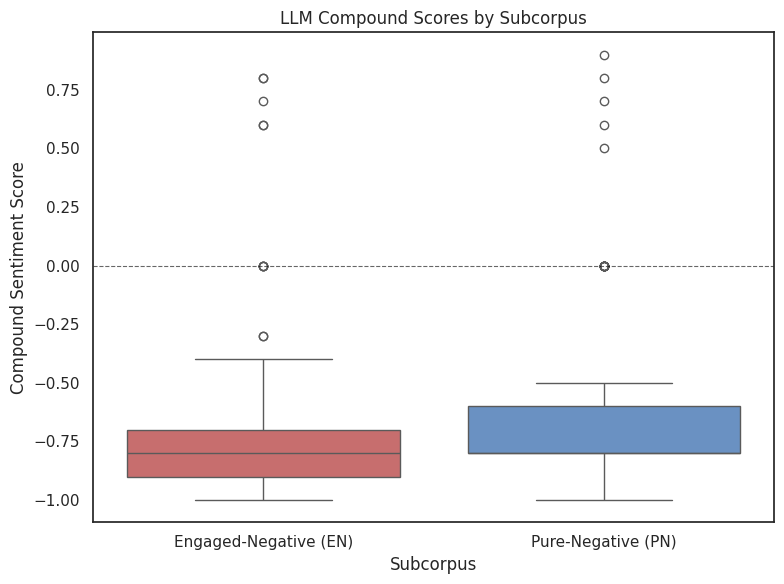

In [54]:
# Combine EN and PN compound scores into a single DataFrame for plotting
lm_plot_data = pd.concat([
    EN_reviews_llm[["llm_compound"]].assign(Subcorpus="Engaged-Negative (EN)"),
    PN_reviews_llm[["llm_compound"]].assign(Subcorpus="Pure-Negative (PN)")
])
# Boxplot — shows distributional spread and median for each subcorpus
# Dashed line at 0 marks the boundary between negative and positive sentiment
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=lm_plot_data,
    x="Subcorpus",
    y="llm_compound",
    palette=["#D65F5F", "#5B8FD1"]
)
plt.title("LLM Compound Scores by Subcorpus")
plt.xlabel("Subcorpus")
plt.ylabel("Compound Sentiment Score")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("llm_compound_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3.5 LLM Three-Class Label Distribution (EN vs PN)

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='Label', ylabel='Percentage'>

Text(0.5, 1.0, 'LLM Label Distribution: EN vs PN')

Text(0, 0.5, 'Percentage of Reviews (%)')

Text(0.5, 0, 'LLM Predicted Label')

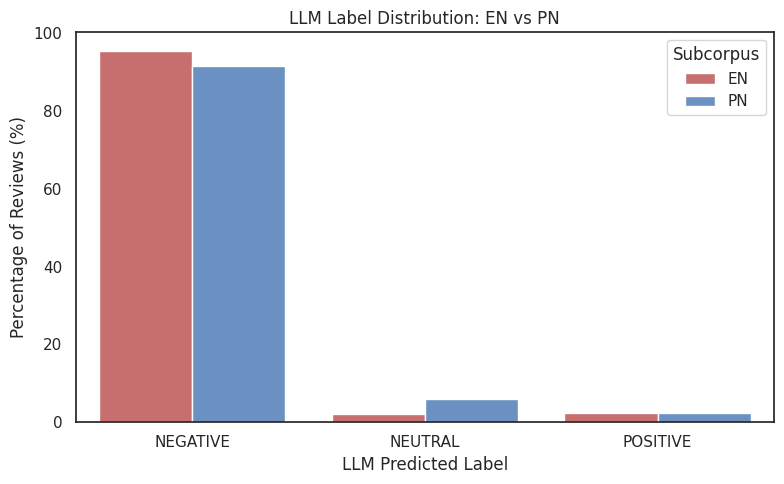

In [55]:
# Calculate percentage of each three-class label for EN and PN
# reindex ensures all three labels appear even if one has 0 counts
label_order = ["NEGATIVE", "NEUTRAL", "POSITIVE"]

en_llm_pct = EN_reviews_llm["llm_label_3"].value_counts(normalize=True).reindex(label_order, fill_value=0) * 100
pn_llm_pct = PN_reviews_llm["llm_label_3"].value_counts(normalize=True).reindex(label_order, fill_value=0) * 100

# Reshape into long format for seaborn barplot
llm_label_df = pd.DataFrame({
    "Label":      label_order * 2,
    "Percentage": list(en_llm_pct) + list(pn_llm_pct),
    "Subcorpus":  ["EN"] * 3 + ["PN"] * 3
})

#Grouped bar chart — directly comparable to vader_label_3 and bert_label_3 charts
plt.figure(figsize=(8, 5))
sns.barplot(data=llm_label_df, x="Label", y="Percentage", hue="Subcorpus",
            palette={"EN": "#D65F5F", "PN": "#5B8FD1"})
plt.title("LLM Label Distribution: EN vs PN", fontsize=12)
plt.ylabel("Percentage of Reviews (%)")
plt.xlabel("LLM Predicted Label")
plt.legend(title="Subcorpus")
plt.tight_layout()
plt.savefig("llm_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3.6 Statistical Tests on LLM Compound Score Distributions

In [56]:
from scipy.stats import ks_2samp, mannwhitneyu

ks_stat_l, ks_p_l = ks_2samp(EN_reviews_llm["llm_compound"], PN_reviews_llm["llm_compound"])
u_stat_l,  u_p_l  = mannwhitneyu(EN_reviews_llm["llm_compound"], PN_reviews_llm["llm_compound"],
                                  alternative="two-sided")

llm_tests = pd.DataFrame({
    "Test":      ["Kolmogorov–Smirnov", "Mann–Whitney U"],
    "Statistic": [round(ks_stat_l, 4), round(u_stat_l, 0)],
    "p-value":   [round(ks_p_l, 6), round(u_p_l, 6)]
})

llm_tests

,Test,Statistic,p-value
0,Kolmogorov–Smirnov,0.08,0.545271
1,Mann–Whitney U,18174.00,0.104263


### 6.3.7 Cross-Model Label Distribution Comparison (VADER vs BERT vs LLM)

<Axes: xlabel='Label', ylabel='Percentage'>

Text(0.5, 1.0, 'Engaged-Negative (EN) — Label Distribution by Model')

Text(0, 0.5, 'Percentage of Reviews (%)')

Text(0.5, 0, 'Predicted Label')

<Axes: xlabel='Label', ylabel='Percentage'>

Text(0.5, 1.0, 'Pure-Negative (PN) — Label Distribution by Model')

Text(0, 0.5, '')

Text(0.5, 0, 'Predicted Label')

Text(0.5, 1.02, 'Cross-Model Label Distribution: VADER vs BERT vs LLM')

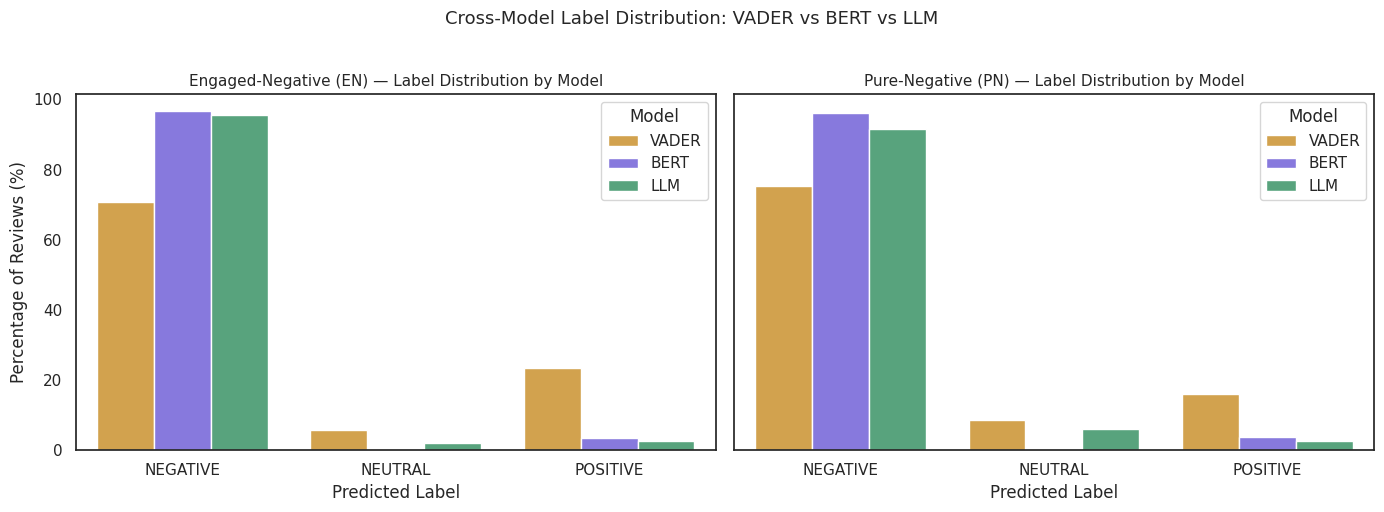

In [57]:
label_order = ["NEGATIVE", "NEUTRAL", "POSITIVE"]

# Helper to get label percentages for a given dataframe and column
def _label_pcts(df, col):
    return df[col].value_counts(normalize=True).reindex(label_order, fill_value=0) * 100

# Build a long-format DataFrame with one row per (model, subcorpus, label) combination
# Each model uses its own sample — percentages are comparable across models
rows = []
for model_name, en_df, pn_df, col in [
    ("VADER", EN_reviews,      PN_reviews,      "vader_label_3"),
    ("BERT",  EN_reviews_bert, PN_reviews_bert, "bert_label_3"),
    ("LLM",   EN_reviews_llm,  PN_reviews_llm,  "llm_label_3"),
]:
    en_pcts = _label_pcts(en_df, col)
    pn_pcts = _label_pcts(pn_df, col)
    for lbl in label_order:
        rows.append({"Model": model_name, "Subcorpus": "EN", "Label": lbl, "Percentage": en_pcts[lbl]})
        rows.append({"Model": model_name, "Subcorpus": "PN", "Label": lbl, "Percentage": pn_pcts[lbl]})

compare_df = pd.DataFrame(rows)

# Side-by-side: left = EN, right = PN
# Each panel shows label percentages grouped by model
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, corpus in zip(axes, ["EN", "PN"]):
    sns.barplot(
        data=compare_df[compare_df["Subcorpus"] == corpus],
        x="Label", y="Percentage", hue="Model",
        palette={"VADER": "#E8A838", "BERT": "#7B68EE", "LLM": "#4CAF7D"},
        ax=ax
    )
    label = "Engaged-Negative (EN)" if corpus == "EN" else "Pure-Negative (PN)"
    ax.set_title(f"{label} — Label Distribution by Model", fontsize=11)
    ax.set_ylabel("Percentage of Reviews (%)" if corpus == "EN" else "")
    ax.set_xlabel("Predicted Label")
    ax.legend(title="Model")

plt.suptitle("Cross-Model Label Distribution: VADER vs BERT vs LLM", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("cross_model_label_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

The third benchmark employs GPT-4o mini in a prompt-driven configuration, instructing the model to analyse each review's sentiment and provide both a categorical label and a continuous score. In contrast to VADER's lexicon-based approach or BERT's fine-tuning, a large language model (LLM) offers broader contextual understanding. However, the results indicate that this broader context does not lead to improved handling of evaluative tension.

The LLM assigns a mean compound score of −0.7245 to engaged-negative (EN) reviews and −0.6712 to pure-negative (PN) reviews, with both categories sharing a median of −0.800. The boxplot reveals that EN scores are tightly clustered around the median, whereas PN scores display greater dispersion, a wider interquartile range, and more positive outliers. This pattern aligns with PN's higher neutral rate (6.0% compared to 1.0% for EN). At the categorical label level, 97.0% of EN reviews are classified as NEGATIVE, compared to 91.5% of PN reviews. Therefore, the LLM rates engaged-negative reviews more negatively than pure-negative ones, which is the opposite of VADER's results and consistent with BERT.

Neither statistical test reaches significance (KS: D = 0.11, p = 0.178; Mann–Whitney U: U = 17,882, p = 0.059), though the borderline Mann–Whitney result suggests a larger sample could be impactful. Overall, despite its greater linguistic sophistication, the LLM aligns with BERT in flattening the EN–PN distinction, reinforcing the finding that evaluative tension in engaged-negative reviews is systematically missed by all three benchmarks.

# Section 7: Diagnostic Analysis

## 7.1 Identifying Model–Human Divergence

In [58]:
# Merge VADER, BERT and LLM scores onto the same set of reviews where possible
# EN_reviews_llm already has vader_compound from the original EN_reviews corpus
# We merge in bert_compound from EN_reviews_bert on the Content column
merged = EN_reviews_llm[["Content", "vader_compound", "vader_label_3",
                           "llm_compound", "llm_label_3"]].copy()

bert_cols = EN_reviews_bert[["Content", "bert_compound", "bert_label_3"]].drop_duplicates("Content")
merged = merged.merge(bert_cols, on="Content", how="left")

# Reviews where all three models agree: strongly negative compound scores
# These are the clearest cases of model-human divergence — EN reviews that
# contain engagement cues but are still rated very negatively by every model
divergent = merged[
    (merged["vader_compound"]  < -0.5) &
    (merged["llm_compound"]    < -0.5) &
    (merged["bert_compound"] < -0.5)
].copy()

divergent = divergent.copy()
for col in ["vader_compound", "bert_compound", "llm_compound"]:
    divergent[col] = divergent[col].round(1)


print(f"Reviews strongly negative across all three models: {len(divergent)}")
pd.set_option("display.max_colwidth",None)
divergent[["Content", "vader_compound", "bert_compound", "llm_compound"]].head(10)

Reviews strongly negative across all three models: 90


,Content,vader_compound,bert_compound,llm_compound
0,"I am extremely disappointed with Facebook's lack of oversight on its Marketplace. The platform allows thousands of scammers to create and use various new accounts to defraud and steal money from honest users. This negligence has made the Marketplace a dangerous place for transactions, and Facebook needs to take immediate action to protect its users.",-0.6,-1.0,-0.9
1,"Sensitive Rules and Regulations plus Community Guidelines: My new accounts keep getting disabled without any rule violations. This app is overly sensitive when it comes to enforcing rules, and it doesn't apply fair or compatible guidelines to its users. The moderation system is flawed and inconsistent, making the experience frustrating for everyone.",-0.6,-1.0,-0.7
4,"I can't share anything from my facebook account to anyone using the Messenger app. It keeps giving me the words, ""Error. Something went wrong. Please try again later."" It's been going on for days. I've uninstalled and reinstalled both apps, logged out and back in on both accounts and nothing changed. I also reviewed and changed what settings I could, but it's still not working. Please advise.",-0.5,-1.0,-0.7
6,"worst thing ever. wasting of time, lag issue, much internet taking and still give buffering in every videos",-0.8,-1.0,-0.8
8,Last update sucks. Now it freezes when u check out a ad in market place. Then u either have to wait on it or close it out n try to find it again. Not happy. And yes I've restarted my phone and cleared the cache and so on. It was all fine till it updated 2 days ago.,-0.7,-1.0,-0.7
9,"Meta just makes fb worse and worse, all messages just went to encrypted something and when i searched for what i need, it just a mess, if i have something that people use more, i would rather delete this from my phone",-0.8,-1.0,-0.8
10,"I cannot log in to my accounts anymore on this phone.Accounts are ok on my another phone but every time I try to log in to this phone, it keeps saying something is wrong, unexpected error occurred please try it later.",-0.6,-1.0,-0.8
12,"Facebook is getting worse and worse. More unknown people keep popping hundreds of them. There's no option to disable it. If it does, it doesn't F^@#!×× work. I agree if the U.S. Gov. Want to shutdown. 👍👍👍",-0.7,-1.0,-0.7
21,"besides all the obvious ways this app is bad, it particularly pisses me off that theyve set the notifications to ""in app configuration"". so when i get a random notification, i cant know right away which category it is so i can turn that category off. (my phone will tell me that). instead i have to muddle through the in-app notification menu which doesnt show you which category it was in. and its often impossible to know at all without doing a lot of trial and error.",-0.8,-1.0,-0.7
24,terrible app never had so many problems with this i have been blocked for a supposed 24 hours from posting that was 6 days ago and still nothing tried submitting reports email etc get no help and still no answers terrible,-0.8,-1.0,-0.9


## 7.2 Representative Examples

In [59]:
# Select a small set of illustrative examples for qualitative analysis
# Prioritise reviews that are clearly ambivalent to a human reader —
# i.e. contain visible engagement cues alongside negative evaluation

# Engagement cue keywords (from operationalisation in Section 5)
engagement_keywords = [
    "still", "keep", "every day", "always", "have to", "need to",
    "can't stop", "can't leave", "stuck", "addicted", "despite",
    "but", "however", "though", "although", "yet", "reinstall"
]

# Use whole-word matching (\b) to avoid partial matches e.g. "but" inside "button"
divergent["Engagement cues"] = divergent["Content"].apply(
    lambda t: ", ".join(sorted(set(
        kw for kw in engagement_keywords
        if re.search(rf'\b{re.escape(kw)}\b', t, re.IGNORECASE)
    )))
)

# Only keep reviews with at least one confirmed engagement cue, then take 5 most negative
examples = (
    divergent[divergent["Engagement cues"] != ""]
    .nsmallest(10, "vader_compound")
    [["Content", "Engagement cues", "vader_compound", "bert_compound", "llm_compound"]]
    .reset_index(drop=True)
)

pd.set_option("display.max_colwidth", None)
examples

,Content,Engagement cues,vader_compound,bert_compound,llm_compound
0,Facebook doesn't fix the issues on it every time I log on to Facebook. it always take for ever to load .my newsfeed freezes. i report the problem and they don't do anything at all. Messenger is so annoying. I don't have messenger anymore. but people keep popping up on it and I'm getting tired of telling people o. it to stop messengering me. Facebook needs to make alot of changing like for the people who doesn't want messenger to block or to be able to delete it with any trouble. ads are annoying,"always, but, keep",-1.0,-1.0,-0.8
1,"Update: the first update broke it. There have been 2 updates since and it's STILL broken. 😡 And to make matters worse, it doesn't load ANYTHING. It tells me everything is broken. No duh. -------- Once again the update has broken the app. I'm stuck on one page and it won't let me see my personal or other business pages. I don't have time for broken apps. The update (the details of which are never disclosed, btw) couldn't have been that important or had that many bugs at release.","still, stuck",-1.0,-1.0,-0.9
2,"Worst app I have ever used in my life. A propaganda content always spreading lies misinformation related to political, social and religious issues. Spread hatred and bully amongst Individuals impacting negative on mental health. Don't Download it only use X which is reliable.",always,-1.0,-1.0,-0.9
3,"So bad and get no response or corrections to problems reported. My trash is always showing empty when I delete something, my log in and log outs are all gone- empty page. I am so tired of reporting problems that never get resolved!!!!!!!",always,-1.0,-1.0,-0.9
4,"What a mess. I thought I was having trouble opening links because I was in the Beta. So I left the Beta hoping itʻd solve the issue. Nope! NOW IT'S EVEN WORSE! I keep getting kicked off. It claims it's updating when it's not. And shouldn't be, anyway. I'm set to NO auto-updates. Then it says it's moving it back to my SD card when my settings say it's already on my SD card. It's an endless cycle of stupid. Uninstalled til you fix this newest disaster.",keep,-0.9,-1.0,-0.9
5,"Still have issues with page refreshing in the middle of reading for no reason. Spam is getting worse. So many fake profiles and companies spamming groups with the same content over and over but facebook seems to allow them to keep recreating accounts. No options to turn off swiping that messes up quite often. Comments always in the way in videos, they should be hidden rather than covering video with the smallest button ever to hide it. Just dumb features. Spam notifications without asking!!","always, but, keep, still",-0.9,-1.0,-0.8
6,"Annoying! My news feed shows none of my friends or pages/groups I choose to see. It's full of half naked people (including teens) and just inappropriate material!!! I block these pages and they're all still there! I do not look at this content nor have I ""liked"" these things! This platform is not safe for teens and I can imagine its a great platform for sex trafficking due to the content I'm seeing! So sad and disgusting!!",still,-0.9,-1.0,-0.9
7,"didn't want FB, but eventually was forced to download it for networking needs. I intended only to use FB in a very limited capacity; I combed through Fb's intentionally confusing settings in order to define the few occasions on which I want to receive notifications. Despite this, I recieve constant undesired notifications throughout the day. I will often clear a notification only for it to reappear right before my eyes. terrible, shady, obtrusive app from a terrible. shady, obtrusive company.","but, despite",-0.9,-1.0,-0.9
8,"I was already sick of the screenshotting bringing up unnecessary popups for sharing posts, now I randomly get a ""session timed out"", can't log back in, it's blocked me from messenger and IG, and no matter what I do (uninstall, reinstall, change password, etc) it just keeps saying I can't log in. Fa

Based on the representative examples and the distributional results from Section 6, three recurring failure modes can be identified across the benchmarked models:

**Lexical Dominance.** High-intensity negative tokens (e.g. *hate*, *terrible*, *awful*) exert disproportionate influence on the polarity score, regardless of surrounding context. This is most pronounced in BERT and the LLM, where the presence of a single strong negative term is sufficient to anchor the output to a strongly negative score. Engagement cues present in the same review — which a human reader would use to modulate their interpretation — are effectively overridden.

**Structural Insensitivity.** Contrastive constructions such as *but*, *however*, *although*, and *despite* signal a shift in evaluative direction mid-review. Polarity-based models treat all tokens independently and do not encode the asymmetric weight that discourse connectives assign to the clause that follows them. As a result, the positive or mitigating content introduced after *but* receives equal or lesser weight than the negative content that precedes it.

**Neutral Drift.** When conflicting signals of negativity and engagement co-occur, some models hedge toward a mid-range score rather than committing to either pole. VADER exhibits this most visibly in its higher POSITIVE label rate for EN reviews — positive lexical items in engagement cues partially offset the negative compound score. The LLM shows a mild version of this in PN reviews (6.0% NEUTRAL), though it does not extend to EN. BERT shows almost none, collapsing virtually all reviews to strong negativity regardless of content.

In [60]:

lexical_dominance_words = [
    "hate", "terrible", "awful", "worst", "horrible", "disgusting",
    "garbage", "useless", "pathetic", "appalling"
]

contrastive_markers = ["but", "however", "although", "despite", "though", "yet"]

def classify_error(text):
    """Assign a primary error type based on linguistic features present."""
    tl = text.lower()
    has_lexical   = any(w in tl for w in lexical_dominance_words)
    has_contrastive = any(w in tl for w in contrastive_markers)
    # Lexical dominance takes priority if a high-intensity negative word is present
    if has_lexical:
        return "Lexical Dominance"
    # Structural insensitivity if contrastive marker present but no dominant lexical item
    elif has_contrastive:
        return "Structural Insensitivity"
    # Neutral drift for remaining cases — engagement cues present but no clear trigger
    else:
        return "Neutral Drift"

divergent["error_type"] = divergent["Content"].apply(classify_error)

# Distribution of error types in the divergent set
error_counts = divergent["error_type"].value_counts().reset_index()
error_counts.columns = ["Error Type", "Count"]
error_counts["Percentage"] = (error_counts["Count"] / len(divergent) * 100).round(2)
error_counts

,Error Type,Count,Percentage
0,Lexical Dominance,38,42.22
1,Neutral Drift,34,37.78
2,Structural Insensitivity,18,20.00


In [61]:
# Show one representative example for each error type
print("=" * 70)
for error_type in ["Lexical Dominance", "Structural Insensitivity", "Neutral Drift"]:
    subset = divergent[divergent["error_type"] == error_type]
    if len(subset) == 0:
        print(f"\n[{error_type}] — no examples found")
        continue
    row = subset.iloc[0]
    print(f"\n[{error_type}]")
    print(f"Review : {row['Content'][:300]}")
    print(f"VADER  : {row['vader_compound']:.4f}")
    print(f"BERT   : {row['bert_compound'] if pd.notna(row['bert_compound']) else 'n/a'}")
    print(f"LLM    : {row['llm_compound']:.4f}")
    print("-" * 70)


[Lexical Dominance]
Review : worst thing ever. wasting of time, lag issue, much internet taking and still give buffering in every videos
VADER  : -0.8000
BERT   : -1.0
LLM    : -0.8000
----------------------------------------------------------------------

[Structural Insensitivity]
Review : I can't share anything from my facebook account to anyone using the Messenger app. It keeps giving me the words, "Error. Something went wrong. Please try again later." It's been going on for days. I've uninstalled and reinstalled both apps, logged out and back in on both accounts and nothing changed
VADER  : -0.5000
BERT   : -1.0
LLM    : -0.7000
----------------------------------------------------------------------

[Neutral Drift]
Review : I am extremely disappointed with Facebook's lack of oversight on its Marketplace. The platform allows thousands of scammers to create and use various new accounts to defraud and steal money from honest users. This negligence has made the Marketplace a dangerou

**Summary.** The diagnostic analysis confirms that the EN–PN distinction is systematically suppressed across all three models, though through different mechanisms. Lexical dominance is the most prevalent failure mode — high-intensity negative tokens are present in the majority of divergent EN reviews and appear sufficient to fix model outputs at strong negativity regardless of engagement cues. Structural insensitivity compounds this: models do not encode the discourse-level function of contrastive connectives, meaning the mitigating clause following *but* or *however* carries no special weight. Neutral drift is the least common pattern and manifests differently across models — as partial positive offsetting in VADER, and as mild neutral assignment in the LLM for PN reviews.

Together these failure modes explain why none of the three benchmarks reliably separates engaged negativity from pure negativity, and support the broader argument that polarity-based frameworks are structurally ill-equipped to represent the evaluative complexity present in ambivalent reviews.